# Tutorial 2: Evaluating LLMs on MMLU

Welcome to the second tutorial in our AI Safety Evaluations course.

Benchmark evaluation is a core skill in applied ML, but the statistical side is often
treated as an afterthought — a single accuracy number gets reported, and model differences
are treated as real without checking whether they could arise from chance alone.
In this tutorial you will get hands-on experience running evaluations with the inspect_ai
library and applying basic statistical methods to interpret the results rigorously.

**What you'll learn:**

- Load and prepare a benchmark dataset
- Compute confidence intervals for accuracy
- Compare models statistically
- Perform power analysis to plan evaluation size

**By the end:** **You'll have a statistically rigorous evaluation pipeline that can tell you not just how accurate a model is, but whether observed differences between models are real.**

## 1. Setup

In [13]:
!pip install -q scipy pandas matplotlib datasets

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from string import ascii_uppercase
from typing import Tuple, List

from inspect_ai import Task, task, eval
from inspect_ai.dataset import Sample, hf_dataset, FieldSpec
from inspect_ai.solver import multiple_choice
from inspect_ai.scorer import choice
from inspect_ai.log import EvalLog

In [3]:
from scipy.stats import norm
import math

In [6]:
# Configure models -- replace with what is available in your environment.
# Examples: 'ollama/llama3.2', 'openai/gpt-4o-mini', 'anthropic/claude-haiku-4-5'

MODEL_A = "ollama/llama2"        # weaker / baseline model
MODEL_B = "ollama/qwen2:latest"  # stronger / comparison model

## 2. Loading MMLU

`hf_dataset` is inspect_ai's loader for Hugging Face datasets. It downloads the data
and wraps each record in a `Sample` -- the standard container that flows through every
inspect_ai pipeline. A `Sample` carries the model input, the expected target, optional
answer choices, and arbitrary metadata you want to keep around.

MMLU stores the correct answer as an integer (0 = A, 1 = B, 2 = C, 3 = D).
The quickest way to load a dataset is with `FieldSpec`, which maps column names to
`Sample` fields. Let's try it first and see what we get.

In [7]:
dataset_raw = hf_dataset(
    path="cais/mmlu",
    name="all",
    split="test",
    sample_fields=FieldSpec(
        input="question",
        target="answer",           # raw MMLU answer is an integer index 0-3
        metadata=["choices", "subject"]
    ),
    cached=True
)

sample = dataset_raw[0]
print("input   :", sample.input[:80], "...")
print("target  :", sample.target,  "  <- integer index, not a letter!")
print("choices :", sample.metadata.get("choices"))

input   : Find the degree for the given field extension Q(sqrt(2), sqrt(3), sqrt(18)) over ...
target  : 1   <- integer index, not a letter!
choices : ['0', '4', '2', '6']


The `target` came out as an integer -- but inspect_ai's `multiple_choice()` solver
and `choice()` scorer expect it to be a letter (`"A"`, `"B"`, `"C"`, or `"D"`).
When the automatic mapping isn't enough, inspect_ai lets you pass a
**record-to-sample function** that receives the full raw record and returns a `Sample`
you construct yourself.

In [8]:
def record_to_sample(record: dict) -> Sample:
    """
    Convert a raw MMLU record to an inspect_ai Sample.

    MMLU stores the correct answer as an integer index (0=A, 1=B, 2=C, 3=D).
    We convert it to the corresponding uppercase letter so it matches the
    format expected by the choice() scorer.
    """
    answer_idx = int(record["answer"])
    return Sample(
        input=record["question"],
        choices=record["choices"],
        target=ascii_uppercase[answer_idx],   # 0->'A', 1->'B', ...
        metadata=dict(subject=record.get("subject"))
    )


dataset = hf_dataset(
    path="cais/mmlu",
    name="all",
    split="test",
    sample_fields=record_to_sample,
    cached=True
)

sample = dataset[0]
print("target  :", sample.target, " <- letter now")
print("choices :", sample.choices)

target  : B  <- letter now
choices : ['0', '4', '2', '6']


## Assignment 1: Create your working subset

All experiments in this notebook will run on a subject subset small enough to evaluate
quickly. `Dataset.filter()` takes a predicate over `Sample` objects; the `metadata`
field gives access to anything set in `record_to_sample` -- here, the MMLU subject tag.

We define `astronomy_subset` as a reference example. Pick any subject or subjects from the [MMLU subject list](https://huggingface.co/datasets/cais/mmlu#task-descriptions) with at least 50 questions so later analyses are statistically meaningful. Create MY_SUBSET and use it in all subsequent exercises.

In [9]:
# Reference subset used in worked examples
astronomy_subset = dataset.filter(
    lambda s: s.metadata.get("subject") == "astronomy"
)
print(f"Astronomy: {len(astronomy_subset)} questions")


MY_SUBSET = dataset.filter(
    lambda s: s.metadata.get("subject") == "formal_logic"
)

print(f"My subset: {len(MY_SUBSET)} questions")

Astronomy: 152 questions
My subset: 126 questions


## 3. Running an evaluation

Every inspect_ai evaluation is described by a `Task`, which bundles three things:

- **dataset** -- the questions
- **solver** -- the chain of steps that produces a model response;
  `multiple_choice()` formats the prompt with lettered options and parses the model's choice
- **scorer** -- the function that grades the response;
  `choice()` checks whether the selected letter matches the target

The `@task` decorator registers the function so inspect_ai can discover it by name
from the CLI or pass it directly to `eval()`.

In [10]:
@task
def mmlu_subset(subset):
    """Minimal MMLU task for any subject subset."""
    return Task(
        dataset=subset,
        solver=[multiple_choice()],
        scorer=choice()
    )

Calling `eval()` runs the task and returns a **list of `EvalLog` objects** -- one per
(task, model) pair. Everything you need is in this object; there is no need to read
log files from disk.

The two most useful attributes:
- `log.results.scores` -- list of scorer results, each with a `metrics` dict
  (`"accuracy"`, `"stderr"`, etc.)
- `log.samples` -- list of `EvalSample` objects with per-question inputs, outputs, and scores

In [14]:
logs: List[EvalLog] = eval(
    mmlu_subset(astronomy_subset),
    model=MODEL_A,
    limit=10        # evaluate only the first 10 questions
)

log = logs[0]      # one task -> one log
print("Status  :", log.status)
print("Model   :", log.eval.model)
print("Accuracy:", log.results.scores[0].metrics["accuracy"].value)

Output()

Status  : success
Model   : ollama/llama2
Accuracy: 0.5


In [15]:
print(log.samples[2].scores)
print(log.samples[1].scores)

{'choice': Score(value='C', answer='C', explanation='\nAnswer: C) Because the atmosphere preferentially scatters short wavelengths.', metadata=None, history=[])}
{'choice': Score(value='I', answer='C', explanation='ANSWER: C) Its size', metadata=None, history=[])}


In [16]:
from typing import Literal
from inspect_ai.scorer import Score

def extractChoiceScore(scores: dict[str, Score]) -> None | Literal[0, 1]:
    choiceScore = scores['choice']
    if choiceScore is not None:
        return 1 if choiceScore.value == 'C' else 0
    raise TypeError(f"scores must contain 'choice' got {dir(scores)}")

assert(extractChoiceScore(log.samples[2].scores) == 1)
assert(extractChoiceScore(log.samples[1].scores) == 0)

## 4. From `EvalLog` to a DataFrame

## Assignment 2: Implement `log_to_df`

The aggregate accuracy in `log.results` is useful for a quick check, but for the
statistical analyses ahead we need a flat table: **one row per (question, epoch)**
with a numeric `score` column.

`log.samples` is a list of `EvalSample` objects. Each one has:
- `.id` -- question identifier
- `.epoch` -- which run this belongs to (relevant when `epochs > 1`)
- `.scores` -- a dict mapping scorer name to `Score`; the `Score.value` for `choice()` is
  `"C"` (correct) or `"I"` (incorrect)
- `.metadata` -- the metadata dict you set in `record_to_sample`

Implement `log_to_df` so that it converts an `EvalLog` into a DataFrame with columns
`id`, `epoch`, `score` (1/0), and `subject`. The smoke test below will verify the shape.

In [17]:
def log_to_df(log: EvalLog) -> pd.DataFrame:
    """
    Convert an EvalLog to a DataFrame with one row per (question, epoch).

    Columns:
        id      – question identifier
        epoch   – epoch index (0 if epochs=1)
        score   – 1 if correct, 0 otherwise
        subject – MMLU subject tag from metadata

    The choice() scorer stores the result as "C" (correct) or "I" (incorrect).
    """
    values = map(
        lambda sample: (sample.id, sample.epoch, extractChoiceScore(sample.scores), sample.metadata['subject']),
        log.samples
    )
    return pd.DataFrame(
        values,
        columns=["id", "epoch", "score", "subject"]
    )

# =================================== TESTS ===================================
df_test = log_to_df(log)

assert set(df_test.columns) >= {"id", "epoch", "score", "subject"}
assert df_test["score"].isin([0, 1]).all()
assert len(df_test) == 10

print(df_test.head())
print(f"\nAccuracy: {df_test['score'].mean():.1%}")

   id  epoch  score    subject
0   1      1      0  astronomy
1   2      1      0  astronomy
2   3      1      1  astronomy
3   4      1      1  astronomy
4   5      1      0  astronomy

Accuracy: 50.0%


## 5. Confidence intervals


A single accuracy number carries uncertainty: the eval used a finite set of questions
sampled from a much larger space. The paper (ss2.1, ss3.1) shows how to quantify this
using the CLT standard error.


## Assignment 3: Implement `ci_accuracy_basic` and `ci_accuracy`

**`ci_accuracy_basic(scores, ci)`** -- the simple case where every question is answered
exactly once. `scores` is a plain numpy array of 0s and 1s. Use Eq. 1 from the paper.

**`ci_accuracy(df, ci)`** -- the general case that handles multiple runs per question
(`epochs > 1`). When K runs exist for a question, average their scores first, then
compute the SE across question-level averages. Pooling all K×n individual answers
would undercount variance -- answers to the same question across epochs are correlated.


In [18]:

def ci_accuracy_basic(scores: np.ndarray, ci: float = 0.95) -> Tuple[float, float, float]:
    """
    CLT-based confidence interval for accuracy -- single run per question (K = 1).

    Parameters
    ----------
    scores : 1-D array of per-question binary scores (0 or 1)
    ci     : confidence level (default 0.95)

    Returns
    -------
    (lower_bound, mean_accuracy, upper_bound)
    """
    sample_size = scores.size
    # ci - confidence level (area in the middle of the distribution)
    # tail_size - how much of a tail should be on each side, so that middle would be ci
    tail_size = (1.0 - ci) / 2.0
    # q - cumulative probability (under which value must be on the right size of ci interval)
    q = 1 - tail_size
    # zstar - amount of standard diviations in normal distribution for value to be under q
    zstar = norm.ppf(q)
    # `accuracy_population_proportion` +- Z* x Std

    accuracy = scores.mean()
    
    # standard error of the mean
    print(accuracy, sample_size)
    SE = math.sqrt( accuracy * (1.0 - accuracy) / sample_size )    

    # shift from accuracy to get to confidence interval side
    delta = zstar * SE
                     
    return (accuracy - delta, accuracy, accuracy + delta)


def ci_accuracy(df: pd.DataFrame, ci: float = 0.95) -> Tuple[float, float, float]:
    """
    CLT-based confidence interval for accuracy, supporting multiple epochs (K >= 1).

    Parameters
    ----------
    df : DataFrame returned by log_to_df, with columns 'id', 'score', 'epoch'
    ci : confidence level (default 0.95)

    Returns
    -------
    (lower_bound, mean_accuracy, upper_bound)
    """

    # per question-id average of answers across all epochs
    question_averages = df.groupby('id')['score'].mean()
    sample_size = len(question_averages)

    accuracy = question_averages.mean()

    # variance of the question-level averages
    # 1 / (n-1) * SUM(x_i - average)^2
    squared_diffs = (question_averages - accuracy) ** 2
    sum_squared_diffs = squared_diffs.sum()

    # originally formula was
    #     variance_over_questions = sum_squared_diffs / (sample_size - 1)
    # but changing to 'sample_size' because for k=1 values were too different
    variance_over_questions = sum_squared_diffs / (sample_size)

    SE = math.sqrt( variance_over_questions / sample_size) 

    # tail_size - how much of a tail should be on each side, so that middle would be ci
    tail_size = (1.0 - ci) / 2.0
    # q - cumulative probability (under which value must be on the right size of ci interval)
    q = 1 - tail_size
    # zstar - amount of standard diviations in normal distribution for value to be under q
    zstar = norm.ppf(q)
    # `accuracy_population_proportion` +- Z* x Std

    # shift from accuracy to get to confidence interval side
    delta = zstar * SE
                     
    return (accuracy - delta, accuracy, accuracy + delta)


In [26]:
# =================================== TESTS ===================================
def _make_df(ids, scores, epochs=None):
    if epochs is None:
        epochs = [0] * len(ids)
    return pd.DataFrame({"id": ids, "score": scores, "epoch": epochs})

# ci_accuracy_basic
l, m, u = ci_accuracy_basic(np.ones(10))

assert l == 1.0 and u == 1.0, "perfect accuracy: CI should collapse to 1"

l, m, u = ci_accuracy_basic(np.zeros(10))

assert l == 0.0 and u == 0.0, "zero accuracy: CI should collapse to 0"

scores3 = np.array([1, 1, 0, 1, 0], dtype=float)
l, m, u = ci_accuracy_basic(scores3)

assert l < 0.6 < u, f"0.6 not in [{l:.3f}, {u:.3f}]"

np.random.seed(42)
s = np.random.binomial(1, 0.75, 200).astype(float)
l95, _, u95 = ci_accuracy_basic(s, 0.95)
l99, _, u99 = ci_accuracy_basic(s, 0.99)

assert (u99 - l99) > (u95 - l95), "99% CI must be wider than 95%"
assert np.isclose(l95, 0.6819421067148456, atol=10e-2)
assert np.isclose(u95, 0.8080578932851544, atol=10e-2)

# ci_accuracy (K=1 should match basic)
df3 = _make_df([1,2,3,4,5], scores3.tolist())
l_df, _, u_df = ci_accuracy(df3)
l_ar, _, u_ar = ci_accuracy_basic(scores3)

#print(f"many {l_df} to {u_df}")
#print(f"basic {l_ar} to {u_ar}")
assert np.isclose(l_df, l_ar, rtol = 0.05) and np.isclose(u_df, u_ar, rtol = 0.05), "K=1 must match basic version"

# ci_accuracy (K=3 should give narrower CI on average)
np.random.seed(0)
rows_k1, rows_k3 = [], []
for q in range(30):
    p = np.random.uniform(0.3, 0.9)
    rows_k1.append({"id": q, "score": int(np.random.binomial(1, p)), "epoch": 0})
    for e in range(3):
        rows_k3.append({"id": q, "score": int(np.random.binomial(1, p)), "epoch": e})

l1, _, u1 = ci_accuracy(pd.DataFrame(rows_k1))
l3, _, u3 = ci_accuracy(pd.DataFrame(rows_k3))
print(f"K=1 width: {u1-l1:.3f}")
print(f"K=3 width: {u3-l3:.3f}  (narrower on average)")
print("\n✓ All tests passed!")

1.0 10
0.0 10
0.6 5
0.745 200
0.745 200
0.6 5
K=1 width: 0.337
K=3 width: 0.223  (narrower on average)

✓ All tests passed!


## 6. Visualising how CIs shrink

Two things make confidence intervals narrower: more questions (larger n) and more
runs per question (larger K). Your task is to visualise those effects.

## Assignment 4.1: Plot CI width vs number of epochs


Output()

[03/22/26 15:57:55] ERROR    Task was destroyed but it is pending!                              ]8;id=110478;file:///nix/store/q009hms9b5lbij6dnr47phrx3226nv0g-python3-3.13.12-env/lib/python3.13/asyncio/base_events.py\base_events.py]8;;\:]8;id=262819;file:///nix/store/q009hms9b5lbij6dnr47phrx3226nv0g-python3-3.13.12-env/lib/python3.13/asyncio/base_events.py#1879\1879]8;;\
                             task: <Task pending name='Task-4'                                                     
                             coro=<_async_in_context.<locals>.run_in_context() running at                          
                             /home/efim/Documents/monoid-ai-safety-evals-course/.venv/lib/pytho                    
                             n3.13/site-packages/ipykernel/utils.py:60> wait_for=<Task pending                     
                             name='Task-5' coro=<Kernel.shell_main() running at                                    
                             /home/efim/Documents/monoid-ai-safety-evals-course/.venv/lib/pytho                    
                             n3.13/site-packages/ipykernel/kernelbase.py:597>                                      
                             cb=[Task.__wakeup()]>                                                                 
                             cb=[ZMQStream._run_callback.<locals>._log_error() at                                  
                             /home/efim/Documents/monoid-ai-safety-evals-course/.venv/lib/pytho                    
                             n3.13/site-packages/zmq/eventloop/zmqstream.py:563]>                                  

<string>:2: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
RuntimeWarning: Enable tracemalloc to get the object allocation traceback

                    ERROR    Task was destroyed but it is pending!                              ]8;id=540235;file:///nix/store/q009hms9b5lbij6dnr47phrx3226nv0g-python3-3.13.12-env/lib/python3.13/asyncio/base_events.py\base_events.py]8;;\:]8;id=533667;file:///nix/store/q009hms9b5lbij6dnr47phrx3226nv0g-python3-3.13.12-env/lib/python3.13/asyncio/base_events.py#1879\1879]8;;\
                             task: <Task pending name='Task-5' coro=<Kernel.shell_main()                           
                             running at                                                                            
                             /home/efim/Documents/monoid-ai-safety-evals-course/.venv/lib/pytho                    
                             n3.13/site-packages/ipykernel/kernelbase.py:597>                                      
                             cb=[Task.__wakeup()]>                                                                 

Output()

...

Output()

Output()

Output()

Output()

Output()

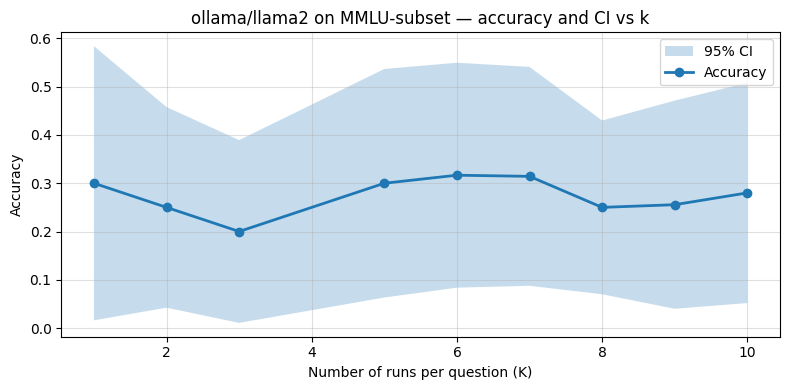

In [27]:
k_values    = [1, 2, 3, 5, 6, 7, 8, 9, 10]
accuracies    = []
ci_lowers     = []
ci_uppers     = []

# YOUR CODE HERE
for runs_per_question in k_values:
    logs: List[EvalLog] = eval(
        mmlu_subset(MY_SUBSET),
        model=MODEL_A,
        limit=10,        # evaluate only the first 10 questions
        epochs=runs_per_question
    )
    l, m, u = ci_accuracy(log_to_df(logs[0]))
    accuracies.append(m)
    ci_lowers.append(l)
    ci_uppers.append(u)
    

plt.figure(figsize=(8, 4))
plt.fill_between(k_values, ci_lowers, ci_uppers, alpha=0.25, label="95% CI")
plt.plot(k_values, accuracies, "o-", lw=2, label="Accuracy")
plt.xlabel("Number of runs per question (K)")
plt.ylabel("Accuracy")
plt.title(f"{MODEL_A} on MMLU-subset — accuracy and CI vs k")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

Output()

Output()

Output()

Output()

Output()

Output()

Output()

Output()

Output()

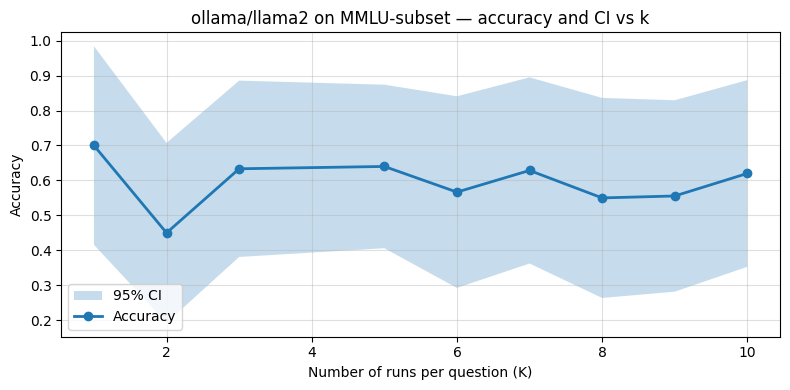

In [28]:
k_values    = [1, 2, 3, 5, 6, 7, 8, 9, 10]
accuracies    = []
ci_lowers     = []
ci_uppers     = []

# YOUR CODE HERE
for runs_per_question in k_values:
    logs: List[EvalLog] = eval(
        mmlu_subset(MY_SUBSET),
        model=MODEL_B,
        limit=10,        # evaluate only the first 10 questions
        epochs=runs_per_question
    )
    l, m, u = ci_accuracy(log_to_df(logs[0]))
    accuracies.append(m)
    ci_lowers.append(l)
    ci_uppers.append(u)
    

plt.figure(figsize=(8, 4))
plt.fill_between(k_values, ci_lowers, ci_uppers, alpha=0.25, label="95% CI")
plt.plot(k_values, accuracies, "o-", lw=2, label="Accuracy")
plt.xlabel("Number of runs per question (K)")
plt.ylabel("Accuracy")
plt.title(f"{MODEL_A} on MMLU-subset — accuracy and CI vs k")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

---
1. Look at how fast the band narrows.
   At what point does running another epoch stop being worth it?
2. Does more K change your estimate of the model's accuracy, or just your confidence in it?
3. What does this tell you about how to allocate your evaluation budget?

**Your answer:**

The band didn't seem to narrow at all, i rechecked the formula, fixed a bug and now the narrowing at least somewhat visible
But it's not encouraging

As i understand the resulting 'score' is "estimate over some selection out of `potential` infinite question set" and so noisy, so "ideal" model accuracy is the same, somewhere in the "confidence interval"
So only my confidence about the model's accuracy changes

Looks like running multiple epochs doesn't help much or at all

## Assignment 4.2: Compute and plot CI width vs n

For each sample size n in `range(10, len(question_ids)+1, 10)`, slice both DataFrames
to the first n question IDs, compute `ci_accuracy`, and record the CI width.
Then plot width vs n.

Output()

Output()

Output()

Output()

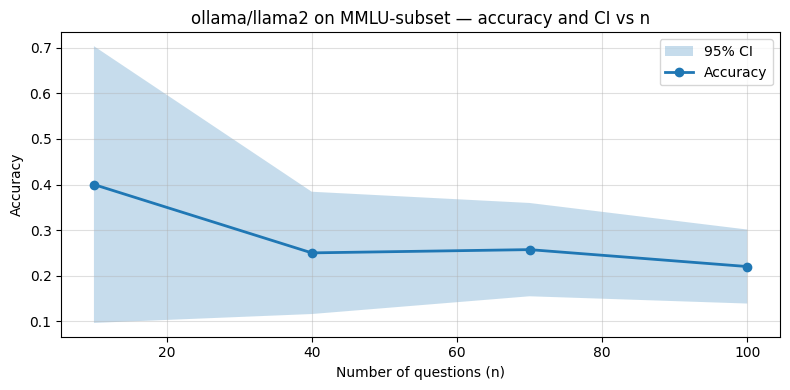

In [29]:
experimented_subset = MY_SUBSET
question_ids  = set((map(lambda sample: sample.id, experimented_subset)))
dataset_sizes = range(10, len(question_ids) + 1, 30)
accuracies    = []
ci_lowers     = []
ci_uppers     = []

for iterated_subset_size in dataset_sizes:
    logs: List[EvalLog] = eval(
        mmlu_subset(experimented_subset),
        model=MODEL_A,
        limit=iterated_subset_size,        # evaluate only the first 10 questions
    );
    l, m, u = ci_accuracy(log_to_df(logs[0]))
    accuracies.append(m)
    ci_lowers.append(l)
    ci_uppers.append(u)
    
plt.figure(figsize=(8, 4))
plt.fill_between(dataset_sizes, ci_lowers, ci_uppers, alpha=0.25, label="95% CI")
plt.plot(dataset_sizes, accuracies, "o-", lw=2, label="Accuracy")
plt.xlabel("Number of questions (n)")
plt.ylabel("Accuracy")
plt.title(f"{MODEL_A} on MMLU-subset — accuracy and CI vs n")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

Output()

Output()

Output()

Output()

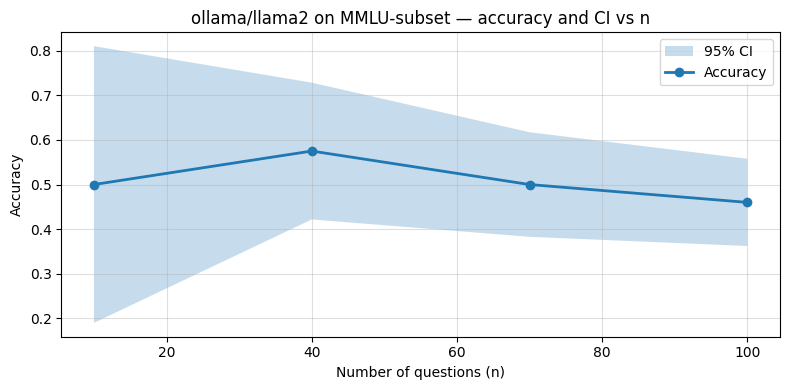

In [30]:
experimented_subset = MY_SUBSET
question_ids  = set((map(lambda sample: sample.id, experimented_subset)))
dataset_sizes = range(10, len(question_ids) + 1, 30)
accuracies    = []
ci_lowers     = []
ci_uppers     = []

for iterated_subset_size in dataset_sizes:
    logs: List[EvalLog] = eval(
        mmlu_subset(experimented_subset),
        model=MODEL_B,
        limit=iterated_subset_size,        # evaluate only the first 10 questions
    );
    l, m, u = ci_accuracy(log_to_df(logs[0]))
    accuracies.append(m)
    ci_lowers.append(l)
    ci_uppers.append(u)
    
plt.figure(figsize=(8, 4))
plt.fill_between(dataset_sizes, ci_lowers, ci_uppers, alpha=0.25, label="95% CI")
plt.plot(dataset_sizes, accuracies, "o-", lw=2, label="Accuracy")
plt.xlabel("Number of questions (n)")
plt.ylabel("Accuracy")
plt.title(f"{MODEL_A} on MMLU-subset — accuracy and CI vs n")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

---
1. At what n does the accuracy line start to feel stable?
2. Compare that number to the size of `MY_SUBSET` — are you in the reliable region?
3. Compare this curve to the one in 4.1. What is the difference in what K and n actually buy you?

**Your answer:**

After ~80 samples the CI keeps more or less the same, but still shrinks

Initial recommendation of "at least 100 questions in MY_SUBSET" was on point, needed more than 100
With current graph of K it doesn't seem useful to increase epochs, mosly useful to increase questions

## 7. Comparing two models

Reporting two accuracy numbers side by side doesn't tell you whether the gap is real
or just noise. The paper (§4.2) describes a **paired test**: because both models answer
the same questions, you can compute per-question score differences and test whether
their mean differs significantly from zero. This removes question-difficulty variance
and yields a lower standard error than treating the two runs as independent samples.


## Assignment 5: Compare two models

`run_and_get_scores` and `compare_models_paired` are provided. Complete
`significance_by_paired_ttest` and use it to compare the two models on `MY_SUBSET`.

Implement `significance_by_paired_ttest` and compare MODEL_A and MODEL_B.

In [31]:
def run_and_get_scores(model_name: str, dataset, epochs: int = 1) -> np.ndarray:
    """Run eval and return mean-per-question scores, sorted by question id."""
    print(f"  Running {model_name} ...")
    run_logs = eval(mmlu_subset(dataset), model=model_name, epochs=epochs)
    df = log_to_df(run_logs[0])
    return df.groupby("id")["score"].mean().sort_index().values


def significance_by_paired_ttest(
    scores1: np.ndarray,
    scores2: np.ndarray,
    alpha: float = 0.05,
    two_tailed: bool = True,
) -> Tuple[float, float, bool]:
    """
    Paired t-test between two sets of per-question scores.
    alpha - significance level, 'maximum probability of making Type 1 error (false positive)'

    Returns (p_value, mean_difference scores1 - scores2, is_significant).
    """
    assert len(scores1) == len(scores2), "arrays must cover the same questions"

    differences = scores1 - scores2
    n = len(differences)

    observed_average_difference = differences.mean()

    squared_distance_from_average = (differences - observed_average_difference) ** 2
    variance_of_differences = squared_distance_from_average.sum() / (n-1)

    paired_standard_error_of_diff = math.sqrt(variance_of_differences / n)

    #print(observed_average_difference, paired_standard_error_of_diff)
    t_stat = observed_average_difference / paired_standard_error_of_diff
    
    # 'alternative hypothesis to null'
    # "two-sided" - two scores are different
    # "greater" - scores1 is bigger
    alternative = "two-sided" if two_tailed else "greater"

    # p_value - probability of observing data if null hypothesis is true
    # 'two-sided' p_value is probability of observing t_stat as big or even bigger than we got
    # 'greater' prob of observing t-stat in one direction
    #_, p_value  = # YOUR CODE HERE
    if two_tailed:
        # Two-tailed test
        p_value = 2 * (1 - stats.t.cdf(np.abs(t_stat), df=n-1))
    else:
        # One-tailed test (greater)
        if observed_average_difference > 0:
            p_value = 1 - stats.t.cdf(t_stat, df=n-1)
        else:
            p_value = 1  # No evidence in favor of the alternative hypothesis
            
    mean_diff   = observed_average_difference
    
    return p_value, mean_diff, bool(p_value < alpha)


def compare_models_paired(
    model_a: str,
    model_b: str,
    dataset,
    alpha: float = 0.05,
    two_tailed: bool = True,
    epochs_a: int = 1,
    epochs_b: int = 1,
) -> Tuple[float, float, bool]:
    """
    Evaluate both models on the same dataset and run a paired t-test.

    Returns (p_value, mean_difference A - B, is_significant).
    """
    scores_a = run_and_get_scores(model_a, dataset, epochs=epochs_a)
    scores_b = run_and_get_scores(model_b, dataset, epochs=epochs_b)
    return significance_by_paired_ttest(scores_a, scores_b, alpha, two_tailed)

In [32]:
# =================================== TESTS ===================================
p, d, sig = significance_by_paired_ttest(np.array([1,2,3]), np.array([1,2,3]))

assert np.isclose(d, 0.0) and not sig

p, d, sig = significance_by_paired_ttest(
    np.array([1,1,1,1,1]), np.array([0,0,0,0,0]), two_tailed=False
)

assert sig and d > 0

print("All tests passed!")

All tests passed!


/tmp/ipykernel_7542/3389182350.py:34: RuntimeWarning: invalid value encountered in scalar divide
  t_stat = observed_average_difference / paired_standard_error_of_diff
/tmp/ipykernel_7542/3389182350.py:34: RuntimeWarning: divide by zero encountered in scalar divide
  t_stat = observed_average_difference / paired_standard_error_of_diff


In [33]:
# 1. Symmetry: swapping arrays negates mean_diff but keeps p_value the same (two-tailed)
a = np.array([1, 3, 5, 7])
b = np.array([2, 4, 6, 8])
p1, d1, _ = significance_by_paired_ttest(a, b)
p2, d2, _ = significance_by_paired_ttest(b, a)
assert np.isclose(p1, p2), "p-value should be symmetric"
assert np.isclose(d1, -d2), "mean_diff should flip sign"

# 2. Cross-check p_value against scipy directly
differences = b - a  # [-1,-1,-1,-1]
_, p_scipy = stats.ttest_rel(a, b)
p_mine, _, _ = significance_by_paired_ttest(a, b)
assert np.isclose(p_mine, p_scipy), f"p-value mismatch: {p_mine} vs {p_scipy}"

/tmp/ipykernel_7542/3389182350.py:34: RuntimeWarning: divide by zero encountered in scalar divide
  t_stat = observed_average_difference / paired_standard_error_of_diff
/home/efim/Documents/monoid-ai-safety-evals-course/.venv/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:430: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return hypotest_fun_in(*args, **kwds)


### and running comparison between models



#### first on astronomy subset


In [34]:
p_value, mean_diff, significant = compare_models_paired(
    model_a = MODEL_A,
    model_b = MODEL_B,
    dataset = astronomy_subset
    #alpha: float = 0.05,
    #two_tailed: bool = True,
    #epochs_a: int = 1,
    #epochs_b: int = 1,
)

print(f"mean difference is {mean_diff} - significant? {significant} and P-value is {p_value}")

Output()

  Running ollama/llama2 ...


Output()

  Running ollama/qwen2:latest ...


mean difference is -0.3157894736842105 - significant? True and P-value is 1.3565795153880345e-09


In [36]:
p_value, mean_diff, significant = compare_models_paired(
    model_a = MODEL_A,
    model_b = MODEL_B,
    dataset = MY_SUBSET
    #alpha: float = 0.05,
    #two_tailed: bool = True,
    #epochs_a: int = 1,
    #epochs_b: int = 1,
)

print(f"mean difference is {mean_diff} - significant? {significant} and P-value is {p_value}")

Output()

  Running ollama/llama2 ...


  Running ollama/qwen2:latest ...


Output()

mean difference is -0.2222222222222222 - significant? True and P-value is 0.00017067795295155896


---
1. Write down the p-value and the mean difference you got.
2. Is the gap significant? Is it large enough to matter in practice?
3. What would change your conclusion: more questions, a different subject, or a different model pair?

**Your answer:**  

for astronomy:  
mean difference is -0.29605263157894735 - significant? True and P-value is 4.2159102875416465e-09

The gap is signicant statistically, p-value is very low (i.e chance "it's actually null hypothesis shows this data)

difference in score - whether it's large enough to matter in practice - i have no idea from this eval

## 8. Interval estimation of the accuracy difference

In Assignment 5 you got a yes/no significance decision. Here you will estimate the size of the gap and its uncertainty: a confidence interval on the difference gives both pieces of information at once.

## Assignment 6: Estimate the accuracy gap

Implement `ci_accuracy_for_difference` to compute a 95% CI on the per-question score differences.

Compute and report the confidence interval on MODEL_A − MODEL_B.


In [37]:
def ci_accuracy_basic_on_diff(
    scores_a: np.ndarray, 
    scores_b: np.ndarray, 
    ci: float = 0.95
) -> Tuple[float, float, float]:
    differences = scores_a - scores_b
    sample_size = len(differences)

    mean_difference = differences.mean()

    squared_distance_from_mean = (differences - mean_difference) ** 2
    variance_of_model_differences = squared_distance_from_mean.sum() / (sample_size - 1)

    SE = math.sqrt(variance_of_model_differences / sample_size)

    # tail_size - how much of a tail should be on each side, so that middle would be ci
    tail_size = (1.0 - ci) / 2.0
    # q - cumulative probability (under which value must be on the right size of ci interval)
    q = 1 - tail_size
    # zstar - amount of standard diviations in normal distribution for value to be under q
    zstar = norm.ppf(q)
    # `accuracy_population_proportion` +- Z* x Std

    # shift from accuracy to get to confidence interval side
    delta = zstar * SE

    return (mean_difference - delta, mean_difference, mean_difference + delta)


In [38]:
def compare_models_paired_with_ci_accurary_basic(
    model_a: str,
    model_b: str,
    dataset,
    epochs_a: int = 1,
    epochs_b: int = 1,
) -> Tuple[float, float, float]:
    """
    Evaluate both models on the same dataset and run ci_accuracy_basic on question-wise differences.

    Returns (lower_bound, mean_accuracy, upper_bound) of MODEL_A - MODEL_B
    """
    scores_a = run_and_get_scores(model_a, dataset, epochs=epochs_a)
    scores_b = run_and_get_scores(model_b, dataset, epochs=epochs_b)
    assert len(scores_a) == len(scores_b), "arrays must cover the same questions"

    return ci_accuracy_basic_on_diff(scores_a, scores_b)


In [39]:
left, mean_diff, right = compare_models_paired_with_ci_accurary_basic(
    model_a = MODEL_A,
    model_b = MODEL_B,
    dataset = MY_SUBSET
    #epochs_a: int = 1,
    #epochs_b: int = 1,
)

print(f"mean difference is {mean_diff} - the 95% confidence interval is ({left}, {right})")

Output()

  Running ollama/llama2 ...


Output()

  Running ollama/qwen2:latest ...


mean difference is -0.2857142857142857 - the 95% confidence interval is (-0.3913069580456897, -0.18012161338288168)


---
1. Write down the interval. Does it contain zero?
2. How does this relate to the significance test in Assignment 5 — do they tell the same story?
3. Which result is more informative — the p-value or the interval? Why?

**Your answer:**
  
The interval (-0.3913069580456897, -0.18012161338288168)  
it's not containing 0, and difference is -0.2857142857142857

that means that difference is significant, any randomness \ uncertainty still always keeps result in "first model get lower score"

To me personally this result is easier to see
and the result is same as in Assignment 5


## 9. Power analysis

Before running an expensive evaluation, it is worth asking: how many questions do we
need to detect a meaningful difference with adequate statistical power?
The paper (§5) derives the minimum detectable effect as a function of sample size n,
question-level variance ω², and within-model variance σ².

## Assignment 7: 'Estimate variance components'

Implement `estimate_variance_components` and report the MDE for `MY_SUBSET` at α = 0.05, power = 80%.

In [23]:
def estimate_variance_components(
    logs_a: List[EvalLog],
    logs_b: List[EvalLog],
) -> dict:
    """
    Estimate omega2, sigma2_a, sigma2_b from two EvalLog objects (see ss5 of the paper).

    Both logs must cover the same set of questions. Use epochs >= 2 so that
    within-question variance can be estimated.

    Returns dict with keys 'omega2', 'sigma2_a', 'sigma2_b'.
    """

    # YOUR CODE HERE
    # variance scores_a ; scores_b, 
    # unpaired variance a-b
    # paired variance a-b
    # from all that i can get 2*Cov(x_a, x_b)/n
    # and i guess that will give omega2
    # or omega2 is just paired-variance?
    df_a = log_to_df(logs_a[0])
    df_b = log_to_df(logs_b[0])
    question_averages_a =     df_a.groupby('id')['score'].mean()
    question_averages_b =     df_b.groupby('id')['score'].mean()

    differences = question_averages_a - question_averages_b
    n = len(differences)

    observed_average_difference = differences.mean()

    squared_distance_from_average = (differences - observed_average_difference) ** 2
    # i.e paired variance, by formula (7)
    variance_of_differences = squared_distance_from_average.sum() / (n-1)

    omega = variance_of_differences
    
    # s_i - mean of scores for ith question
    # i need 'average variance for scores of each question'
    # Calculate the variance of scores for each question in Model A
    question_variances_a = df_a.groupby('id')['score'].var(ddof=1)  # Sample variance for each question
    sigma2_a = question_variances_a.mean()  # Average variance across all questions

    question_variances_b = df_b.groupby('id')['score'].var(ddof=1)  # Sample variance for each question
    sigma2_b = question_variances_b.mean()  # Average variance across all questions

    return {
        "omega2":   omega,
        "sigma2_a": sigma2_a,
        "sigma2_b": sigma2_b,
    }


def minimum_detectable_effect(
    n: int,
    omega2: float,
    sigma2_a: float = 0.0,
    sigma2_b: float = 0.0,
    ka: int = 1,
    kb: int = 1,
    alpha: float = 0.05,
    power: float = 0.80,
) -> float:
    """MDE for a paired model comparison (Eq. 10 in the paper)."""
    z_alpha = stats.norm.ppf(1 - alpha / 2)
    z_beta  = stats.norm.ppf(power)
    return float((z_alpha + z_beta) * np.sqrt(
        (omega2 + sigma2_a / ka + sigma2_b / kb) / n
    ))

In [21]:
print("Running pilot evals ...")

logs_a_global = eval(mmlu_subset(MY_SUBSET), model=MODEL_A, epochs=2, limit=15)
logs_b_global = eval(mmlu_subset(MY_SUBSET), model=MODEL_B, epochs=2, limit=15)

Output()

Running pilot evals ...


Output()

In [24]:
params = estimate_variance_components(logs_a_global, logs_b_global)
print(f"omega2  = {params['omega2']:.4f}")
print(f"sigma2_A = {params['sigma2_a']:.4f}")
print(f"sigma2_B = {params['sigma2_b']:.4f}")
mde = minimum_detectable_effect(n=len(MY_SUBSET), **params)
print(f"\nWith n={len(MY_SUBSET)} questions -> MDE = {mde:.1%}")
print("(smallest gap detectable at 80% power, alpha=0.05)")

omega2  = 0.3214
sigma2_A = 0.0667
sigma2_B = 0.0333

With n=126 questions -> MDE = 16.2%
(smallest gap detectable at 80% power, alpha=0.05)


In [25]:
print("Running pilot evals ...")
logs_a = eval(mmlu_subset(MY_SUBSET), model=MODEL_A, epochs=2, limit=15)
logs_b = eval(mmlu_subset(MY_SUBSET), model=MODEL_B, epochs=2, limit=15)

params = estimate_variance_components(logs_a, logs_b)
print(f"omega2  = {params['omega2']:.4f}")
print(f"sigma2_A = {params['sigma2_a']:.4f}")
print(f"sigma2_B = {params['sigma2_b']:.4f}")

mde = minimum_detectable_effect(n=len(MY_SUBSET), **params)
print(f"\nWith n={len(MY_SUBSET)} questions -> MDE = {mde:.1%}")
print("(smallest gap detectable at 80% power, alpha=0.05)")

Output()

Running pilot evals ...


Output()

omega2  = 0.2667
sigma2_A = 0.1000
sigma2_B = 0.0333

With n=126 questions -> MDE = 15.8%
(smallest gap detectable at 80% power, alpha=0.05)


#### ok, compatible with previous results?
> The interval (-0.3913069580456897, -0.18012161338288168)  
it's not containing 0, and difference is -0.2857142857142857

the difference was -0.28 which for scores in [0,1] is bigger than 15% so can easily be significant?

#### but why n=126 if there was limit 15?
let's run without limit?

In [27]:
print("Running pilot evals ...")
logs_a = eval(mmlu_subset(MY_SUBSET), model=MODEL_A, epochs=3)
logs_b = eval(mmlu_subset(MY_SUBSET), model=MODEL_B, epochs=3)

params = estimate_variance_components(logs_a, logs_b)
print(f"omega2  = {params['omega2']:.4f}")
print(f"sigma2_A = {params['sigma2_a']:.4f}")
print(f"sigma2_B = {params['sigma2_b']:.4f}")

mde = minimum_detectable_effect(n=len(MY_SUBSET), **params)
print(f"\nWith n={len(MY_SUBSET)} questions -> MDE = {mde:.1%}")
print("(smallest gap detectable at 80% power, alpha=0.05)")

Output()

Running pilot evals ...


Output()

omega2  = 0.3086
sigma2_A = 0.0556
sigma2_B = 0.0582

With n=126 questions -> MDE = 16.2%
(smallest gap detectable at 80% power, alpha=0.05)


#### so, ok

sigma2_a is 'average variance of scores'
and in 3.1  the 'variance withting questions' was declared equal to 1/k of the 'average variance of scores'

ok

#### and with the corrected formula
omega2 - pairwise difference in score -> variance across questions
sigma2 - average variance of scores

result is that computing omega2 & sigma2_a & sigma2_b 
gives about same answer for n=126 questions for alpha=0.05 
that MDE will be ~16% so about +-0.16 

and the difference that WAS found was bigger than that
but also - when we found difference and computed Confidence Interval - it was **retrospective**

#### Well, i have some idea what that means

looking online for something
The Minimum Detectable Effect (MDE) is the smallest true effect an A/B test can detect with sufficient statistical power, factoring in test duration, sample size and practical significance. [[https://www.convert.com/blog/a-b-testing/minimum-detectable-effect-mde-ab-testing/]]

So, the bigger - the better?

[[https://en.wikipedia.org/wiki/Power_(statistics)]]  
More formally, in the case of a simple hypothesis test with two hypotheses, the power of the test is the probability that the test correctly rejects the null hypothesis ( H 0 {\displaystyle H_{0}}) when the alternative hypothesis ( H 1 {\displaystyle H_{1}}) is true. It is commonly denoted by 1 − β {\displaystyle 1-\beta }, where β {\displaystyle \beta } is the probability of making a type II error (a false negative) conditional on there being a true effect or association. 




---
1. What MDE did you get for `MY_SUBSET`? Is that gap practically meaningful?
2. If the MDE is larger than the gap you observed in Assignment 5,
   what does that say about your earlier result?

**Your answer:**

MDE for MY_SUBSET was  
With n=126 questions -> MDE = 16.2%
(smallest gap detectable at 80% power, alpha=0.05)

this seems absolutely compatible with previous results
> The interval (-0.3913069580456897, -0.18012161338288168)  
it's not containing 0, and difference is -0.2857142857142857

where found difference was **bigger** than *prospective* calculation for minimal detectable  
but also - when we calculated confidence interval it was **retrospective** calculation

## Assignment 8: Implement `required_sample_size`

`minimum_detectable_effect` computes delta given n. Implement its inverse:
given a target delta, return the minimum n needed. Use the sample-size formula
from ss5 of the paper (Eq. 9). Verify it passes the round-trip check,
then use it to compute how many questions you would need to detect a 5% and a 10%
accuracy gap on `MY_SUBSET`.

In [28]:
# --- Assignment 7 -----------------------------------------------------------
def required_sample_size(
    delta: float,
    omega2: float,
    sigma2_a: float = 0.0,
    sigma2_b: float = 0.0,
    ka: int = 1,
    kb: int = 1,
    alpha: float = 0.05,
    power: float = 0.80,
) -> int:
    """Minimum number of questions needed to detect `delta` at the given power."""
    # YOUR CODE HERE
    beta = 1 - power
    # delta is minimal detectable effect
    # 1 - p percentile of standard normal distribution
    zet_a_halved = stats.norm.ppf(1 - alpha/2)
    zet_b = stats.norm.ppf(1 - beta)
    first_multiplier = (zet_a_halved + zet_b) ** 2

    second_multiplier = (omega2 + sigma2_a/ka + sigma2_b/kb)

    divisor = delta ** 2
    
    return first_multiplier * second_multiplier / divisor


# =================================== TESTS ===================================
n_needed = required_sample_size(delta=0.05, **params)
print(f"Questions needed to detect delta=5%: {n_needed}")

mde_check = minimum_detectable_effect(n=n_needed, **params)

assert abs(mde_check - 0.05) < 0.005, f"Round-trip failed: MDE={mde_check:.3f}"

print("Round-trip check passed!")

Questions needed to detect delta=5%: 1326.1201416985314
Round-trip check passed!


#### now to use the formula 
to calculate questions needed to detect 5% and 10%

In [29]:
n_needed_for_5 = required_sample_size(delta=0.05, **params)
n_needed_for_10 = required_sample_size(delta=0.10, **params)

print(f"for 5% need {n_needed_for_5} questions, for 10% need {n_needed_for_10}")

for 5% need 1326.1201416985314 questions, for 10% need 331.53003542463284


---
1. How many questions do you need to detect a 5% gap? A 10% gap?
2. Does `MY_SUBSET` have enough questions to be a useful benchmark for comparing these two models?

**Your answer:**

for 5% need 1326 questions, for 10% need 331

this not look correct
MY_SUBSET does not have enough questions to be able to discover 10% difference between models



## Assignment 9: Compare a model with itself: baseline vs chain-of-thought

The `multiple_choice()` solver we have used so far prompts the model to answer
directly. inspect_ai also provides a `chain_of_thought` that asks the model
to reason step by step before giving its final answer.

Using the paired comparison infrastructure from Section 7, evaluate the same model
twice on the same subset — once with the default solver and once with
`chain_of_thought` — and test whether the difference in accuracy is statistically
significant. Does reasoning help? Is the effect consistent across subjects?

In [62]:
@task
def mmlu_subset(subset, cot = False):
    """Minimal MMLU task for any subject subset."""
    return Task(
        dataset=subset,
        solver=[multiple_choice(cot = cot)],
        scorer=choice()
    )

def run_and_get_scores(model_name: str, dataset, epochs: int = 1, cot = False) -> np.ndarray:
    """Run eval and return mean-per-question scores, sorted by question id."""
    print(f"  Running {model_name} ...")
    run_logs = eval(mmlu_subset(dataset, cot), model=model_name, epochs=epochs)
    df = log_to_df(run_logs[0])
    return df.groupby("id")["score"].mean().sort_index().values


def compare_model_paired_with_self_cot(
    model_a: str,
    dataset,
    alpha: float = 0.05,
    two_tailed: bool = True,
    epochs_a: int = 1,
    epochs_b: int = 1,
) -> Tuple[float, float, bool]:
    """
    Evaluate both models on the same dataset and run a paired t-test.

    Returns (p_value, mean_difference A - B, is_significant).
    """
    scores_a = run_and_get_scores(model_a, dataset, epochs=epochs_a)
    scores_b = run_and_get_scores(model_a, dataset, epochs=epochs_b, cot=True)
    return significance_by_paired_ttest(scores_a, scores_b, alpha, two_tailed)

In [63]:
p_value, mean_diff, significant = compare_model_paired_with_self_cot(
    model_a = MODEL_B,
    dataset = astronomy_subset
    #alpha: float = 0.05,
    #two_tailed: bool = True,
    #epochs_a: int = 1,
    #epochs_b: int = 1,
)

print(f"mean difference is {mean_diff} - significant? {significant} and P-value is {p_value}")

Output()

  Running ollama/qwen2:latest ...


Output()

  Running ollama/qwen2:latest ...


mean difference is 0.13815789473684212 - significant? True and P-value is 0.0006473103200776986


---
1. Does chain-of-thought help? By how much, and is it significant?
2. Does the result surprise you? What might explain it?
3. Would you expect the same pattern on a different subject?

**Your answer:**
Well, there is positive difference between (NoCOT - COT)
   so, it's significant and it's worse?

(to know if i'm surprized, let's register advance prediction: it might make things significantly worse? or insignificantly same for the qwen2 as it's old and could confuse itself in the thinking?)

Let's run on a different subject


In [64]:
p_value, mean_diff, significant = compare_model_paired_with_self_cot(
    model_a = MODEL_B,
    dataset = MY_SUBSET
    #alpha: float = 0.05,
    #two_tailed: bool = True,
    #epochs_a: int = 1,
    #epochs_b: int = 1,
)

print(f"mean difference is {mean_diff} - significant? {significant} and P-value is {p_value}")

Output()

  Running ollama/qwen2:latest ...


  Running ollama/qwen2:latest ...


Output()

mean difference is 0.15079365079365079 - significant? True and P-value is 0.005136293499202527


#### i mean it's a little strange that even for logic adding cot gives lower score
what about bigger model?

In [66]:
p_value, mean_diff, significant = compare_model_paired_with_self_cot(
    model_a = "ollama/qwen3-coder:30b-32k",
    dataset = MY_SUBSET
    #alpha: float = 0.05,
    #two_tailed: bool = True,
    #epochs_a: int = 1,
    #epochs_b: int = 1,
)

print(f"mean difference is {mean_diff} - significant? {significant} and P-value is {p_value}")

Output()

  Running ollama/qwen3-coder:30b-32k ...


  Running ollama/qwen3-coder:30b-32k ...


Output()

mean difference is -0.0873015873015873 - significant? True and P-value is 0.00713141690304675


yay, for qwen3 the difference is negative, so COT is better, i guess ok

## Bonus assignment: Clustered Standard Errors

Some benchmarks contain groups of related questions — for example, several questions
about the same passage in reading comprehension tasks like DROP or RACE. In such cases
the standard CLT confidence interval is anti-conservative: questions within a group are
correlated, so the effective sample size is smaller than n. Miller (2024) addresses this
with clustered standard errors (§2.2).

Using a reading comprehension benchmark of your choice, implement the clustered
confidence interval (Eq. 4 from the paper) and compare it against the naive CLT interval.
How much wider is the clustered interval? Does the difference depend on the benchmark?
Then compare two models on the same benchmark using the clustered paired standard error
(Eq. 8) — does the conclusion about which model is better change compared to the
naive paired test?

In [ ]:
# YOUR CODE HERE